# ChainSight — Exploratory Data Analysis & Business Analytics

## Objective

This notebook analyzes the cleaned ChainSight analytical dataset to identify patterns in supply-chain performance, sales, profitability, customer behavior, and delivery risk.

The analysis is organized around business questions rather than individual variables.

## Key Questions

1. How does order volume change over time?
2. How does delivery performance vary across markets and regions?
3. How do shipping modes relate to delivery risk?
4. Which products and categories generate the most revenue?
5. Which products, categories, and segments contribute to profitability?
6. How does discounting relate to profitability?
7. Which customer segments generate the most business value?
8. Which operational factors are associated with late-delivery risk?

## Analytical Principles

- Use the cleaned analytical dataset produced in Phase 3.
- Distinguish descriptive relationships from causal conclusions.
- Preserve the order-item level of the source data unless aggregation is explicitly required.
- Use actual observed data to support business conclusions.
- Avoid using outcome-derived variables when analyzing factors that could be used for predictive modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
DATA_PATH = "../data/processed/chainsight_analytical.csv"

df = pd.read_csv(
    DATA_PATH,
    encoding="latin1",
    parse_dates=[
        "order_date_dateorders",
        "shipping_date_dateorders"
    ]
)

print(
    f"Analytical dataset loaded: "
    f"{df.shape[0]:,} rows × {df.shape[1]} columns"
)

Analytical dataset loaded: 180,519 rows × 45 columns


In [3]:
print(df.shape)

print("\nMissing values:")
print(df.isna().sum()[df.isna().sum() > 0])

print("\nDuplicate rows:", df.duplicated().sum())

(180519, 45)

Missing values:
customer_zipcode    3
dtype: int64

Duplicate rows: 0


## 1. Order Volume Over Time

Understanding how order volume changes over time provides a baseline view of demand patterns and potential seasonality.

Monthly order-item volume is analyzed using the order date.

In [4]:
monthly_orders = (
    df.set_index("order_date_dateorders")
      .resample("MS")
      .size()
      .reset_index(name="order_item_count")
)

monthly_orders.head()

,order_date_dateorders,order_item_count
0,2015-01-01,5322
1,2015-02-01,4729
2,2015-03-01,5362
3,2015-04-01,5126
4,2015-05-01,5357


In [5]:
print(monthly_orders)

   order_date_dateorders  order_item_count
0             2015-01-01              5322
1             2015-02-01              4729
2             2015-03-01              5362
3             2015-04-01              5126
4             2015-05-01              5357
5             2015-06-01              5134
6             2015-07-01              5299
7             2015-08-01              5273
8             2015-09-01              5140
9             2015-10-01              5302
10            2015-11-01              5235
11            2015-12-01              5371
12            2016-01-01              5317
13            2016-02-01              4894
14            2016-03-01              5210
15            2016-04-01              5097
16            2016-05-01              5302
17            2016-06-01              5054
18            2016-07-01              5305
19            2016-08-01              5334
20            2016-09-01              5160
21            2016-10-01              5398
22         

In [6]:
print(
    monthly_orders
    .sort_values("order_item_count", ascending=False)
    .head(10)
)

   order_date_dateorders  order_item_count
21            2016-10-01              5398
11            2015-12-01              5371
2             2015-03-01              5362
4             2015-05-01              5357
26            2017-03-01              5347
19            2016-08-01              5334
0             2015-01-01              5322
30            2017-07-01              5318
28            2017-05-01              5317
12            2016-01-01              5317


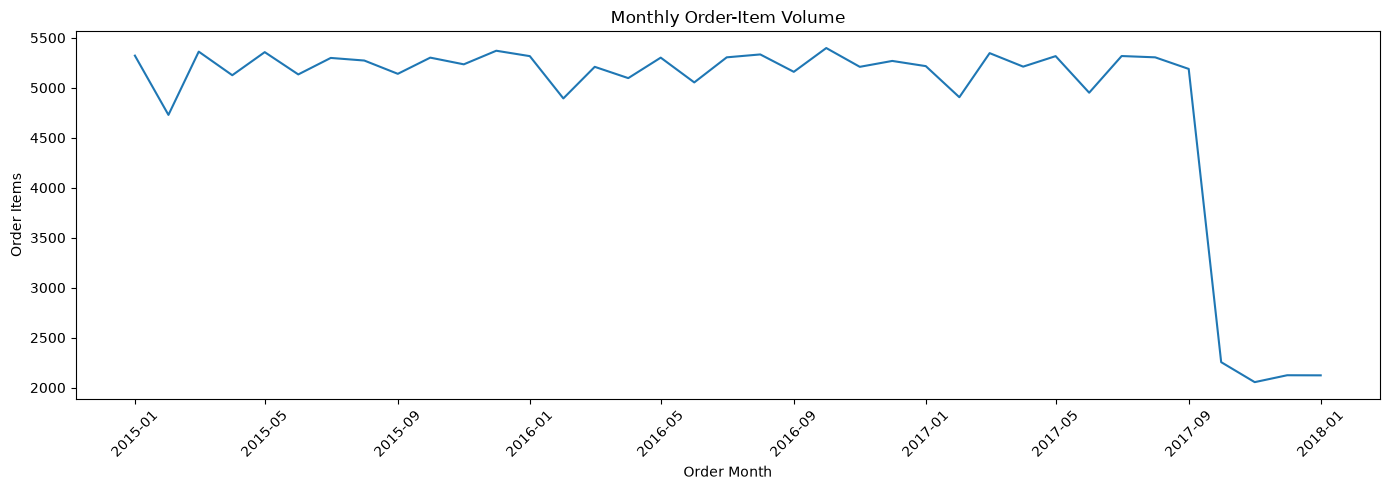

In [7]:
plt.figure(figsize=(14, 5))

sns.lineplot(
    data=monthly_orders,
    x="order_date_dateorders",
    y="order_item_count"
)

plt.title("Monthly Order-Item Volume")
plt.xlabel("Order Month")
plt.ylabel("Order Items")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Data Coverage Check

The monthly order-volume series shows a sharp decline beginning in late 2017.

Before interpreting this as a change in demand, monthly data coverage is examined to determine whether the decline may be associated with incomplete periods in the source data.

In [8]:
monthly_coverage = (
    df.groupby(
        df["order_date_dateorders"].dt.to_period("M")
    )
    .agg(
        order_item_count=("order_item_id", "count"),
        first_order_date=("order_date_dateorders", "min"),
        last_order_date=("order_date_dateorders", "max"),
        unique_order_days=("order_date_dateorders", lambda x: x.dt.date.nunique())
    )
    .reset_index()
)

print(monthly_coverage.tail(8))

   order_date_dateorders  order_item_count    first_order_date  \
29               2017-06              4951 2017-06-01 00:10:00   
30               2017-07              5318 2017-07-01 00:07:00   
31               2017-08              5305 2017-08-01 00:15:00   
32               2017-09              5189 2017-09-01 00:02:00   
33               2017-10              2255 2017-10-01 00:20:00   
34               2017-11              2055 2017-11-01 00:07:00   
35               2017-12              2124 2017-12-01 00:05:00   
36               2018-01              2123 2018-01-01 00:13:00   

       last_order_date  unique_order_days  
29 2017-06-30 23:25:00                 30  
30 2017-07-31 23:54:00                 31  
31 2017-08-31 23:41:00                 31  
32 2017-09-30 23:59:00                 30  
33 2017-10-31 23:46:00                 31  
34 2017-11-30 23:44:00                 30  
35 2017-12-31 23:52:00                 31  
36 2018-01-31 23:38:00                 31  


In [9]:
pre_drop = monthly_coverage[
    monthly_coverage["order_date_dateorders"] <= "2017-09"
]["order_item_count"].mean()

post_drop = monthly_coverage[
    monthly_coverage["order_date_dateorders"] >= "2017-10"
]["order_item_count"].mean()

print(f"Average monthly order items before Oct 2017: {pre_drop:,.0f}")
print(f"Average monthly order items from Oct 2017: {post_drop:,.0f}")

print(
    f"Change: {(post_drop - pre_drop) / pre_drop * 100:.2f}%"
)

Average monthly order items before Oct 2017: 5,211
Average monthly order items from Oct 2017: 2,139
Change: -58.95%


### Key Finding

The dataset shows a substantial structural change in recorded order-item volume beginning in October 2017.

Average monthly order-item volume was approximately 5,211 before October 2017 and 2,139 from October 2017 through January 2018, representing a 58.95% reduction.

All months in the analyzed periods contain orders across the full calendar month, so the reduction is not explained by partial-month coverage.

The available dataset does not establish the underlying cause of this change. Therefore, the observation is treated as a data-supported volume regime change rather than being attributed to a specific business or market event.

## 2. Market-Level Supply Chain Performance

Markets are compared using order-item volume, late-delivery risk, revenue, and profitability.

This analysis identifies differences in operational and financial performance across geographic markets.

In [10]:
market_summary = (
    df.groupby("market")
      .agg(
          order_items=("order_item_id", "count"),
          revenue=("sales", "sum"),
          profit=("order_profit_per_order", "sum"),
          late_delivery_rate=("late_delivery_risk", "mean")
      )
      .reset_index()
)

market_summary["late_delivery_rate"] *= 100

market_summary = market_summary.sort_values(
    "order_items",
    ascending=False
)

market_summary

,market,order_items,revenue,profit,late_delivery_rate
2,LATAM,51594,1.027761e+07,1.123322e+06,54.355158
1,Europe,50252,1.087240e+07,1.169443e+06,55.207753
3,Pacific Asia,41260,8.273744e+06,8.577534e+05,55.046049
4,USCA,25799,5.066529e+06,5.643138e+05,54.800574
0,Africa,11614,2.294453e+06,2.520712e+05,54.589289


In [11]:
market_summary["revenue_per_item"] = (
    market_summary["revenue"]
    / market_summary["order_items"]
)

market_summary["profit_per_item"] = (
    market_summary["profit"]
    / market_summary["order_items"]
)

market_summary["profit_margin"] = (
    market_summary["profit"]
    / market_summary["revenue"]
    * 100
)

market_summary.sort_values(
    "profit_per_item",
    ascending=False
)

,market,order_items,revenue,profit,late_delivery_rate,revenue_per_item,profit_per_item,profit_margin
1,Europe,50252,1.087240e+07,1.169443e+06,55.207753,216.357494,23.271571,10.756073
4,USCA,25799,5.066529e+06,5.643138e+05,54.800574,196.384694,21.873475,11.138075
2,LATAM,51594,1.027761e+07,1.123322e+06,54.355158,199.201706,21.772330,10.929791
0,Africa,11614,2.294453e+06,2.520712e+05,54.589289,197.559232,21.704080,10.986113
3,Pacific Asia,41260,8.273744e+06,8.577534e+05,55.046049,200.526993,20.788983,10.367174


In [12]:
print(
    market_summary[
        [
            "market",
            "order_items",
            "revenue_per_item",
            "profit_per_item",
            "profit_margin",
            "late_delivery_rate"
        ]
    ].round(2)
)

         market  order_items  revenue_per_item  profit_per_item  \
2         LATAM        51594            199.20            21.77   
1        Europe        50252            216.36            23.27   
3  Pacific Asia        41260            200.53            20.79   
4          USCA        25799            196.38            21.87   
0        Africa        11614            197.56            21.70   

   profit_margin  late_delivery_rate  
2          10.93               54.36  
1          10.76               55.21  
3          10.37               55.05  
4          11.14               54.80  
0          10.99               54.59  


## 3. Shipping Mode and Delivery Risk

Shipping modes are compared based on order volume, observed late-delivery rate, and average shipping performance.

The analysis is descriptive and does not imply that shipping mode itself causes delivery outcomes.

In [13]:
shipping_summary = (
    df.groupby("shipping_mode")
      .agg(
          order_items=("order_item_id", "count"),
          late_delivery_rate=("late_delivery_risk", "mean"),
          avg_scheduled_days=("days_for_shipment_scheduled", "mean"),
          avg_actual_days=("days_for_shipping_real", "mean")
      )
      .reset_index()
)

shipping_summary["late_delivery_rate"] *= 100

shipping_summary["avg_delay_days"] = (
    shipping_summary["avg_actual_days"]
    - shipping_summary["avg_scheduled_days"]
)

shipping_summary = shipping_summary.sort_values(
    "order_items",
    ascending=False
)

shipping_summary.round(2)

,shipping_mode,order_items,late_delivery_rate,avg_scheduled_days,avg_actual_days,avg_delay_days
3,Standard Class,107752,38.07,4.0,4.00,-0.00
2,Second Class,35216,76.63,2.0,3.99,1.99
0,First Class,27814,95.32,1.0,2.00,1.00
1,Same Day,9737,45.74,0.0,0.48,0.48


### Key Finding

Observed late-delivery rates vary substantially across shipping modes.

First Class has a 95.32% late-delivery rate, followed by Second Class at 76.63%, Same Day at 45.74%, and Standard Class at 38.07%.

The differences correspond closely with the gap between scheduled and actual shipping duration. First Class and Second Class have substantially shorter scheduled windows than their observed average shipping durations.

This relationship should be interpreted carefully because the shipping-mode schedule is directly connected to the definition of late-delivery risk. Therefore, the analysis describes an operational relationship rather than establishing that shipping mode itself causes late delivery.

## 4. Department-Level Revenue and Profitability

Departments are compared using order-item volume, revenue, total profit, profit per order item, and profit margin.

This provides a high-level view of where commercial activity and profitability are concentrated.

In [14]:
department_summary = (
    df.groupby("department_name")
      .agg(
          order_items=("order_item_id", "count"),
          revenue=("sales", "sum"),
          profit=("order_profit_per_order", "sum")
      )
      .reset_index()
)

department_summary["profit_per_item"] = (
    department_summary["profit"]
    / department_summary["order_items"]
)

department_summary["profit_margin"] = (
    department_summary["profit"]
    / department_summary["revenue"]
    * 100
)

department_summary = department_summary.sort_values(
    "revenue",
    ascending=False
)

department_summary.round(2)

,department_name,order_items,revenue,profit,profit_per_item,profit_margin
3,Fan Shop,66861,17113870.94,1834155.44,27.43,10.72
0,Apparel,48998,7976255.34,881882.93,18.00,11.06
6,Golf,33220,4609028.24,497523.56,14.98,10.79
5,Footwear,14525,4006498.77,410222.50,28.24,10.24
8,Outdoors,9686,1253351.45,145251.46,15.00,11.59
10,Technology,1465,1039598.97,113170.01,77.25,10.89
4,Fitness,2479,397050.89,46538.06,18.77,11.72
2,Discs Shop,2026,228887.73,24193.12,11.94,10.57
7,Health and Beauty,362,106080.48,9493.63,26.23,8.95
9,Pet Shop,492,41524.80,3589.26,7.30,8.64


### Key Finding

Department-level analysis shows substantial differences between commercial scale and unit profitability.

Fan Shop has the largest order-item volume and the highest total revenue and profit. Technology has a much smaller order-item volume but substantially higher profit per item. Footwear also shows relatively high profit per item despite lower overall volume.

At the lower end, Book Shop and Pet Shop have the lowest profit per item and profit margins among the departments.

These differences indicate that revenue concentration and unit economics should be analyzed separately when assessing financial performance.

## 5. Discounting and Profitability

Order items are grouped into discount-rate bands to examine how discount levels relate to revenue, profitability, and loss-making transactions.

This analysis identifies observed associations and does not establish that discounts directly cause changes in profitability.

In [15]:
df["discount_band"] = pd.cut(
    df["order_item_discount_rate"],
    bins=[-0.001, 0.05, 0.10, 0.15, 0.20, 0.25],
    labels=[
        "0–5%",
        "5–10%",
        "10–15%",
        "15–20%",
        "20–25%"
    ]
)

In [16]:
discount_summary = (
    df.groupby("discount_band", observed=True)
      .agg(
          order_items=("order_item_id", "count"),
          avg_discount_rate=("order_item_discount_rate", "mean"),
          avg_profit=("order_profit_per_order", "mean"),
          total_profit=("order_profit_per_order", "sum"),
          loss_making_rate=("order_profit_per_order", lambda x: (x < 0).mean() * 100)
      )
      .reset_index()
)

discount_summary.round(3)

,discount_band,order_items,avg_discount_rate,avg_profit,total_profit,loss_making_rate
0,0–5%,50142,0.020,23.945,1200626.255,18.625
1,5–10%,40116,0.068,23.508,943058.542,18.434
2,10–15%,30087,0.117,21.474,646082.469,18.812
3,15–20%,40116,0.165,20.140,807926.249,18.878
4,20–25%,20058,0.225,18.407,369209.459,19.030


### Finding

Higher discount bands are associated with lower average profit per order item. Average profit decreases from approximately 23.95 at 0–5% discount to 18.41 at 20–25% discount, a decline of about 23%.

However, the loss-making rate remains relatively stable across discount bands at approximately 18–19%. Therefore, discounting appears more strongly associated with reduced average profitability than with a major change in the frequency of loss-making transactions.

These results are descriptive associations and do not establish that discounts directly cause lower profitability.

In [17]:
profit_check = (
    df.groupby("order_id")["order_profit_per_order"]
      .nunique()
      .value_counts()
      .sort_index()
)

profit_check

order_profit_per_order
1    19850
2    11460
3    11400
4    11721
5    11321
Name: count, dtype: int64

## 6. Customer Segment Analysis

Customer segments are compared using order-item volume, revenue, profitability, and late-delivery risk.

The analysis is descriptive and is intended to identify differences in business contribution and operational performance across customer segments.

In [18]:
segment_summary = (
    df.groupby("customer_segment")
      .agg(
          order_items=("order_item_id", "count"),
          revenue=("sales", "sum"),
          profit=("order_profit_per_order", "sum"),
          late_delivery_rate=("late_delivery_risk", "mean")
      )
      .reset_index()
)

segment_summary["profit_per_item"] = (
    segment_summary["profit"] / segment_summary["order_items"]
)

segment_summary["profit_margin"] = (
    segment_summary["profit"] / segment_summary["revenue"] * 100
)

segment_summary["late_delivery_rate"] *= 100

segment_summary = segment_summary.sort_values(
    "revenue",
    ascending=False
)

segment_summary.round(2)

,customer_segment,order_items,revenue,profit,late_delivery_rate,profit_per_item,profit_margin
0,Consumer,93504,19095790.16,2073487.67,54.81,22.18,10.86
1,Corporate,54789,11168406.84,1202574.96,54.72,21.95,10.77
2,Home Office,32226,6520538.02,690840.34,55.07,21.44,10.59


### Finding

Consumer customers represent the largest share of recorded order-item volume and revenue, followed by Corporate and Home Office customers.

Despite differences in scale, profitability is relatively consistent across segments. Profit per item ranges from approximately 21.44 to 22.18, while profit margins remain between 10.59% and 10.86%.

Late-delivery rates are also tightly clustered at approximately 55% across all three segments. This suggests that customer segment is associated more strongly with differences in business volume than with substantial differences in profitability or observed delivery risk.

These results are descriptive associations and do not establish causal relationships.

In [19]:
category_summary = (
    df.groupby("category_name")
      .agg(
          order_items=("order_item_id", "count"),
          revenue=("sales", "sum"),
          profit=("order_profit_per_order", "sum")
      )
      .reset_index()
)

category_summary["profit_per_item"] = (
    category_summary["profit"] / category_summary["order_items"]
)

category_summary["profit_margin"] = (
    category_summary["profit"] / category_summary["revenue"] * 100
)

category_summary = category_summary.sort_values(
    "revenue",
    ascending=False
)

category_summary.round(2)

,category_name,order_items,revenue,profit,profit_per_item,profit_margin
18,Fishing,17325,6929653.69,756220.77,43.65,10.91
12,Cleats,24551,4431942.78,494636.92,20.15,11.16
9,Camping & Hiking,13729,4118425.57,427455.57,31.14,10.38
10,Cardio Equipment,12487,3694843.20,383011.10,30.67,10.37
47,Women's Apparel,21035,3147800.00,350421.03,16.66,11.13
46,Water Sports,15540,3113844.68,325146.96,20.92,10.44
34,Men's Footwear,22246,2891757.66,311902.82,14.02,10.79
30,Indoor/Outdoor Games,19298,2888993.91,318451.43,16.50,11.02
38,Shop By Sport,10984,1309522.04,129813.96,11.82,9.91
13,Computers,442,663000.00,69656.81,157.59,10.51


### Finding

Revenue is concentrated in a relatively small number of product categories. Fishing generates the highest recorded revenue at approximately 6.93M, followed by Cleats, Camping & Hiking, and Cardio Equipment.

Category-level unit economics vary substantially. Some lower-volume categories, such as Computers and Garden, show relatively high profit per item, but their smaller order volumes mean that their contribution should be interpreted separately from high-volume categories.

Overall, category analysis demonstrates the importance of evaluating scale, total profit, profit per item, and margin together rather than relying on a single profitability metric.

## 8. Operational Factors and Late-Delivery Risk

This section examines which observable order and operational characteristics are associated with late-delivery risk.

Only information that can reasonably be known before the delivery outcome is considered for predictive analysis. Variables such as actual shipping duration, delivery status, and shipping date are excluded from the predictive feature set because they contain information about the outcome itself.

The analysis identifies associations rather than causal relationships.

In [20]:
baseline_risk = (
    df["late_delivery_risk"]
      .value_counts(normalize=True)
      .sort_index()
      .mul(100)
)

baseline_risk

late_delivery_risk
0    45.170868
1    54.829132
Name: proportion, dtype: float64

In [21]:
scheduled_risk = (
    df.groupby("days_for_shipment_scheduled")
      .agg(
          order_items=("order_item_id", "count"),
          late_delivery_rate=("late_delivery_risk", "mean")
      )
      .reset_index()
)

scheduled_risk["late_delivery_rate"] *= 100

scheduled_risk.round(2)

,days_for_shipment_scheduled,order_items,late_delivery_rate
0,0,9737,45.74
1,1,27814,95.32
2,2,35216,76.63
3,4,107752,38.07


In [22]:
market_risk = (
    df.groupby("market")
      .agg(
          order_items=("order_item_id", "count"),
          late_delivery_rate=("late_delivery_risk", "mean")
      )
      .reset_index()
      .sort_values("late_delivery_rate", ascending=False)
)

market_risk["late_delivery_rate"] *= 100

market_risk.round(2)

,market,order_items,late_delivery_rate
1,Europe,50252,55.21
3,Pacific Asia,41260,55.05
4,USCA,25799,54.80
0,Africa,11614,54.59
2,LATAM,51594,54.36


In [23]:
segment_risk = (
    df.groupby("customer_segment")
      .agg(
          order_items=("order_item_id", "count"),
          late_delivery_rate=("late_delivery_risk", "mean")
      )
      .reset_index()
)

segment_risk["late_delivery_rate"] *= 100

segment_risk.round(2)

,customer_segment,order_items,late_delivery_rate
0,Consumer,93504,54.81
1,Corporate,54789,54.72
2,Home Office,32226,55.07


### Finding

Scheduled shipping duration shows a substantially stronger association with observed late-delivery risk than either market or customer segment.

Orders with 1-day and 2-day scheduled shipping windows have late-delivery rates of 95.32% and 76.63%, respectively, compared with 38.07% for 4-day scheduled shipments.

In contrast, late-delivery rates vary only slightly across markets (54.36%–55.21%) and customer segments (54.72%–55.07%).

The scheduled-shipping relationship should be interpreted as an association rather than a causal effect, since the scheduled duration is closely related to the operational shipping SLA.

In [24]:
region_risk = (
    df.groupby("order_region")
      .agg(
          order_items=("order_item_id", "count"),
          late_delivery_rate=("late_delivery_risk", "mean")
      )
      .reset_index()
)

region_risk["late_delivery_rate"] *= 100

region_risk = region_risk.sort_values(
    "late_delivery_rate",
    ascending=False
)

region_risk.round(2)

,order_region,order_items,late_delivery_rate
2,Central Africa,1677,57.96
13,South Asia,7731,56.27
5,East Africa,1852,55.94
22,Western Europe,27109,55.85
14,South of USA,4045,55.77
8,Eastern Europe,3920,55.66
6,East of USA,6915,55.66
15,Southeast Asia,9539,55.53
4,Central Asia,553,55.33
20,West Asia,6009,55.28


### Finding

Regional late-delivery rates show more variation than customer segments or markets, ranging from 48.80% in Canada to 57.96% in Central Africa.

However, the regional differences remain smaller than the differences observed across scheduled shipping durations. In addition, several regions have relatively small order volumes, so their rates should be interpreted cautiously.

Region may therefore provide useful predictive information, but it should be evaluated alongside other operational variables rather than treated as a standalone explanation for delivery risk.

In [25]:
ml_excluded = [
    "late_delivery_risk",
    "delivery_status",
    "days_for_shipping_real",
    "shipping_date_dateorders",
    "order_to_shipping_days"
]

ml_candidate_features = [
    col for col in df.columns
    if col not in ml_excluded
]

pd.DataFrame({
    "feature": ml_candidate_features,
    "dtype": [df[col].dtype for col in ml_candidate_features],
    "missing": [df[col].isna().sum() for col in ml_candidate_features]
})

,feature,dtype,missing
0,type,str,0
1,days_for_shipment_scheduled,int64,0
2,category_id,int64,0
3,category_name,str,0
4,customer_city,str,0
5,customer_country,str,0
6,customer_id,int64,0
7,customer_segment,str,0
8,customer_state,str,0
9,customer_zipcode,float64,3


In [26]:
order_status_check = (
    df.groupby("order_status")["late_delivery_risk"]
      .agg(["count", "mean"])
      .reset_index()
)

order_status_check["mean"] *= 100

order_status_check.round(2)

,order_status,count,mean
0,CANCELED,3692,0.00
1,CLOSED,19616,56.63
2,COMPLETE,59491,57.49
3,ON_HOLD,9804,55.59
4,PAYMENT_REVIEW,1893,57.16
5,PENDING,20227,57.90
6,PENDING_PAYMENT,39832,57.55
7,PROCESSING,21902,57.09
8,SUSPECTED_FRAUD,4062,0.00


In [28]:
ml_excluded.append("order_status")

In [29]:
id_columns = [
    "order_id",
    "order_item_id",
    "customer_id",
    "product_card_id",
    "category_id",
    "department_id",
    "product_category_id"
]

In [30]:
ml_excluded.extend(id_columns)

ml_excluded

['late_delivery_risk',
 'delivery_status',
 'days_for_shipping_real',
 'shipping_date_dateorders',
 'order_to_shipping_days',
 'order_status',
 'order_status',
 'order_id',
 'order_item_id',
 'customer_id',
 'product_card_id',
 'category_id',
 'department_id',
 'product_category_id']

In [31]:
df["type"].value_counts(dropna=False)

type
DEBIT       69295
TRANSFER    49883
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

In [32]:
target = "late_delivery_risk"
ml_features = [
    # Transaction / order information
    "type",
    "order_date_dateorders",
    "days_for_shipment_scheduled",
    "shipping_mode",

    # Customer / geography
    "customer_segment",
    "market",
    "order_region",
    "order_country",
    "order_state",

    # Product
    "category_name",
    "department_name",
    "product_name",

    # Order economics
    "order_item_discount_rate",
    "order_item_quantity",
    "sales",
    "order_item_total",
    "product_price",
    "order_item_profit_ratio",

    # Derived temporal features
    "order_year",
    "order_month",
    "order_quarter",
    "order_day_of_week",
    "order_day"
]

In [33]:
X = df[ml_features].copy()
y = df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (180519, 23)
y shape: (180519,)


,type,order_date_dateorders,days_for_shipment_scheduled,shipping_mode,customer_segment,market,order_region,order_country,order_state,category_name,department_name,product_name,order_item_discount_rate,order_item_quantity,sales,order_item_total,product_price,order_item_profit_ratio,order_year,order_month,order_quarter,order_day_of_week,order_day
0,DEBIT,2018-01-31 22:56:00,4,Standard Class,Consumer,Pacific Asia,Southeast Asia,Indonesia,Java Occidental,Sporting Goods,Fitness,Smart watch,0.04,1,327.75,314.640015,327.75,0.29,2018,1,1,2,31
1,TRANSFER,2018-01-13 12:27:00,4,Standard Class,Consumer,Pacific Asia,South Asia,India,RajastÃ¡n,Sporting Goods,Fitness,Smart watch,0.05,1,327.75,311.359985,327.75,-0.80,2018,1,1,5,13
2,CASH,2018-01-13 12:06:00,4,Standard Class,Consumer,Pacific Asia,South Asia,India,RajastÃ¡n,Sporting Goods,Fitness,Smart watch,0.06,1,327.75,309.720001,327.75,-0.80,2018,1,1,5,13
3,DEBIT,2018-01-13 11:45:00,4,Standard Class,Home Office,Pacific Asia,Oceania,Australia,Queensland,Sporting Goods,Fitness,Smart watch,0.07,1,327.75,304.809998,327.75,0.08,2018,1,1,5,13
4,PAYMENT,2018-01-13 11:24:00,4,Standard Class,Corporate,Pacific Asia,Oceania,Australia,Queensland,Sporting Goods,Fitness,Smart watch,0.09,1,327.75,298.250000,327.75,0.45,2018,1,1,5,13


In [34]:
print("Target distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print((y.value_counts(normalize=True) * 100).round(2))

Target distribution:
late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Target percentage:
late_delivery_risk
1    54.83
0    45.17
Name: proportion, dtype: float64


In [35]:
split_date = X["order_date_dateorders"].quantile(0.80)

print("Minimum date:", X["order_date_dateorders"].min())
print("Maximum date:", X["order_date_dateorders"].max())
print("80% split date:", split_date)

Minimum date: 2015-01-01 00:00:00
Maximum date: 2018-01-31 23:38:00
80% split date: 2017-04-22 15:17:00


In [36]:
train_mask = X["order_date_dateorders"] < split_date
test_mask = X["order_date_dateorders"] >= split_date

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()

y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining date range:")
print(X_train["order_date_dateorders"].min(), "→", X_train["order_date_dateorders"].max())

print("\nTest date range:")
print(X_test["order_date_dateorders"].min(), "→", X_test["order_date_dateorders"].max())

Training set: (144412, 23)
Test set: (36107, 23)

Training date range:
2015-01-01 00:00:00 → 2017-04-22 14:56:00

Test date range:
2017-04-22 15:17:00 → 2018-01-31 23:38:00


In [37]:
print("Training late-delivery rate:")
print(round(y_train.mean() * 100, 2), "%")

print("Test late-delivery rate:")
print(round(y_test.mean() * 100, 2), "%")

Training late-delivery rate:
54.87 %
Test late-delivery rate:
54.66 %


In [38]:
print("Training class distribution:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest class distribution:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training class distribution:
late_delivery_risk
1    54.87
0    45.13
Name: proportion, dtype: float64

Test class distribution:
late_delivery_risk
1    54.66
0    45.34
Name: proportion, dtype: float64


In [39]:
X_train_model = X_train.drop(columns=["order_date_dateorders"]).copy()
X_test_model = X_test.drop(columns=["order_date_dateorders"]).copy()

print("Training features:", X_train_model.shape)
print("Test features:", X_test_model.shape)

Training features: (144412, 22)
Test features: (36107, 22)


In [40]:
categorical_features = X_train_model.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numerical_features = X_train_model.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['type', 'shipping_mode', 'customer_segment', 'market', 'order_region', 'order_country', 'order_state', 'category_name', 'department_name', 'product_name']

Numerical features:
['days_for_shipment_scheduled', 'order_item_discount_rate', 'order_item_quantity', 'sales', 'order_item_total', 'product_price', 'order_item_profit_ratio', 'order_year', 'order_month', 'order_quarter', 'order_day_of_week', 'order_day']


In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [42]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [43]:
preprocessor = ColumnTransformer([
    ("categorical", categorical_pipeline, categorical_features),
    ("numerical", numerical_pipeline, numerical_features)
])

In [44]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [45]:
logistic_model.fit(X_train_model, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['type','days_for_shipment_scheduled','shipping_mode',...,'order_quarter', 'order_day_of_week','order_day']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'d

In [46]:
y_pred_logistic = logistic_model.predict(X_test_model)
y_prob_logistic = logistic_model.predict_proba(X_test_model)[:, 1]

In [47]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Logistic Regression Results")
print("-" * 30)

print("Accuracy :", round(accuracy_score(y_test, y_pred_logistic), 4))
print("Precision:", round(precision_score(y_test, y_pred_logistic), 4))
print("Recall   :", round(recall_score(y_test, y_pred_logistic), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_logistic), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_logistic), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

Logistic Regression Results
------------------------------
Accuracy : 0.6896
Precision: 0.8118
Recall   : 0.5624
F1 Score : 0.6645
ROC-AUC  : 0.7398

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.84      0.71     16371
           1       0.81      0.56      0.66     19736

    accuracy                           0.69     36107
   macro avg       0.71      0.70      0.69     36107
weighted avg       0.72      0.69      0.69     36107


Confusion Matrix:
[[13798  2573]
 [ 8636 11100]]


In [48]:
baseline_results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy_score(y_test, y_pred_logistic)],
    "Precision": [precision_score(y_test, y_pred_logistic)],
    "Recall": [recall_score(y_test, y_pred_logistic)],
    "F1": [f1_score(y_test, y_pred_logistic)],
    "ROC_AUC": [roc_auc_score(y_test, y_prob_logistic)]
})

baseline_results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.6896,0.8118,0.5624,0.6645,0.7398


In [49]:
from sklearn.ensemble import RandomForestClassifier

In [50]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=250,
        max_depth=20,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

In [51]:
rf_model.fit(X_train_model, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['type','days_for_shipment_scheduled','shipping_mode',...,'order_quarter', 'order_day_of_week','order_day']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'d

In [52]:
y_pred_rf = rf_model.predict(X_test_model)
y_prob_rf = rf_model.predict_proba(X_test_model)[:, 1]

In [53]:
rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1": f1_score(y_test, y_pred_rf),
    "ROC_AUC": roc_auc_score(y_test, y_prob_rf)
}

rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.693411249896142,
 'Precision': 0.8124008651766402,
 'Recall': 0.5709363599513579,
 'F1': 0.6705945366898768,
 'ROC_AUC': 0.7430318413924472}

In [54]:
print(classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.62      0.84      0.71     16371
           1       0.81      0.57      0.67     19736

    accuracy                           0.69     36107
   macro avg       0.72      0.71      0.69     36107
weighted avg       0.72      0.69      0.69     36107


Confusion Matrix:
[[13769  2602]
 [ 8468 11268]]


## Model Comparison

Random Forest provides a modest improvement over the Logistic Regression baseline.

Accuracy increases from 68.96% to 69.34%, while F1-score increases from 66.45% to 67.06%. ROC-AUC also improves from 73.98% to 74.30%.

The relatively small improvement suggests that the predictive signal in the selected features is limited and that increasing model complexity does not automatically produce a large performance gain.

In [55]:
model_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred_logistic),
        "Precision": precision_score(y_test, y_pred_logistic),
        "Recall": recall_score(y_test, y_pred_logistic),
        "F1": f1_score(y_test, y_pred_logistic),
        "ROC_AUC": roc_auc_score(y_test, y_prob_logistic)
    },
    rf_results
])

model_results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.6896,0.8118,0.5624,0.6645,0.7398
1,Random Forest,0.6934,0.8124,0.5709,0.6706,0.7430


In [56]:
import importlib.util

print("XGBoost installed:",
      importlib.util.find_spec("xgboost") is not None)

XGBoost installed: False


In [57]:
gb_features = [
    "type",
    "shipping_mode",
    "customer_segment",
    "market",
    "order_region",
    "category_name",
    "department_name",
    "days_for_shipment_scheduled",
    "order_item_discount_rate",
    "order_item_quantity",
    "sales",
    "order_item_total",
    "product_price",
    "order_item_profit_ratio",
    "order_year",
    "order_month",
    "order_quarter",
    "order_day_of_week",
    "order_day"
]

X_gb = df[gb_features].copy()

In [58]:
X_gb_train = X_gb.loc[train_mask].copy()
X_gb_test = X_gb.loc[test_mask].copy()

print(X_gb_train.shape)
print(X_gb_test.shape)

(144412, 19)
(36107, 19)


In [59]:
gb_categorical = X_gb_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

gb_numerical = X_gb_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

print("Categorical:", gb_categorical)
print("Numerical:", gb_numerical)

Categorical: ['type', 'shipping_mode', 'customer_segment', 'market', 'order_region', 'category_name', 'department_name']
Numerical: ['days_for_shipment_scheduled', 'order_item_discount_rate', 'order_item_quantity', 'sales', 'order_item_total', 'product_price', 'order_item_profit_ratio', 'order_year', 'order_month', 'order_quarter', 'order_day_of_week', 'order_day']


In [60]:
gb_preprocessor = ColumnTransformer([
    (
        "categorical",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ),
        gb_categorical
    ),
    (
        "numerical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        gb_numerical
    )
])

In [61]:
X_gb_train_encoded = gb_preprocessor.fit_transform(X_gb_train)
X_gb_test_encoded = gb_preprocessor.transform(X_gb_test)

print("Encoded training shape:", X_gb_train_encoded.shape)
print("Encoded test shape:", X_gb_test_encoded.shape)

Encoded training shape: (144412, 81)
Encoded test shape: (36107, 81)


In [62]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=10,
    random_state=42
)

gb_model.fit(X_gb_train_encoded, y_train)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",150
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (

In [63]:
y_pred_gb = gb_model.predict(X_gb_test_encoded)
y_prob_gb = gb_model.predict_proba(X_gb_test_encoded)[:, 1]

In [64]:
gb_results = {
    "Model": "Gradient Boosting",
    "Accuracy": accuracy_score(y_test, y_pred_gb),
    "Precision": precision_score(y_test, y_pred_gb),
    "Recall": recall_score(y_test, y_pred_gb),
    "F1": f1_score(y_test, y_pred_gb),
    "ROC_AUC": roc_auc_score(y_test, y_prob_gb)
}

gb_results

{'Model': 'Gradient Boosting',
 'Accuracy': 0.6915556540283048,
 'Precision': 0.8392645782371972,
 'Recall': 0.5389136603161735,
 'F1': 0.6563608874078188,
 'ROC_AUC': 0.7387385626981303}

In [65]:
print(classification_report(y_test, y_pred_gb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.61      0.88      0.72     16371
           1       0.84      0.54      0.66     19736

    accuracy                           0.69     36107
   macro avg       0.73      0.71      0.69     36107
weighted avg       0.74      0.69      0.69     36107


Confusion Matrix:
[[14334  2037]
 [ 9100 10636]]


In [66]:
model_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.6896,
        "Precision": 0.8118,
        "Recall": 0.5624,
        "F1": 0.6645,
        "ROC_AUC": 0.7398
    },
    {
        "Model": "Random Forest",
        "Accuracy": 0.6934,
        "Precision": 0.8124,
        "Recall": 0.5709,
        "F1": 0.6706,
        "ROC_AUC": 0.7430
    },
    gb_results
])

model_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.689600,0.811800,0.562400,0.664500,0.739800
1,Random Forest,0.693400,0.812400,0.570900,0.670600,0.743000
2,Gradient Boosting,0.691556,0.839265,0.538914,0.656361,0.738739


In [67]:
rf_classifier = rf_model.named_steps["classifier"]
rf_preprocessor = rf_model.named_steps["preprocessor"]

feature_names = rf_preprocessor.get_feature_names_out()

rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_classifier.feature_importances_
}).sort_values("Importance", ascending=False)

rf_importance.head(20)

,Feature,Importance
1376,numerical__days_for_shipment_scheduled,0.295096
7,categorical__shipping_mode_Standard Class,0.245325
4,categorical__shipping_mode_First Class,0.219391
6,categorical__shipping_mode_Second Class,0.105670
5,categorical__shipping_mode_Same Day,0.023804
3,categorical__type_TRANSFER,0.018986
1,categorical__type_DEBIT,0.004071
1387,numerical__order_day,0.003664
2,categorical__type_PAYMENT,0.002978
1386,numerical__order_day_of_week,0.002341


In [68]:
non_sla_features = [
    "type",
    "customer_segment",
    "market",
    "order_region",
    "order_country",
    "order_state",
    "category_name",
    "department_name",
    "product_name",
    "order_item_discount_rate",
    "order_item_quantity",
    "sales",
    "order_item_total",
    "product_price",
    "order_item_profit_ratio",
    "order_year",
    "order_month",
    "order_quarter",
    "order_day_of_week",
    "order_day"
]

X_non_sla = df[non_sla_features].copy()

X_non_sla_train = X_non_sla.loc[train_mask].copy()
X_non_sla_test = X_non_sla.loc[test_mask].copy()

print("Training shape:", X_non_sla_train.shape)
print("Test shape:", X_non_sla_test.shape)

Training shape: (144412, 20)
Test shape: (36107, 20)


In [69]:
non_sla_categorical = [
    "type",
    "customer_segment",
    "market",
    "order_region",
    "order_country",
    "order_state",
    "category_name",
    "department_name",
    "product_name"
]

non_sla_numerical = [
    "order_item_discount_rate",
    "order_item_quantity",
    "sales",
    "order_item_total",
    "product_price",
    "order_item_profit_ratio",
    "order_year",
    "order_month",
    "order_quarter",
    "order_day_of_week",
    "order_day"
]

non_sla_preprocessor = ColumnTransformer([
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]),
        non_sla_categorical
    ),
    (
        "numerical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        non_sla_numerical
    )
])

X_non_sla_train_encoded = non_sla_preprocessor.fit_transform(
    X_non_sla_train
)

X_non_sla_test_encoded = non_sla_preprocessor.transform(
    X_non_sla_test
)

print("Encoded training shape:", X_non_sla_train_encoded.shape)
print("Encoded test shape:", X_non_sla_test_encoded.shape)

Encoded training shape: (144412, 1383)
Encoded test shape: (36107, 1383)


In [70]:
rf_non_sla = RandomForestClassifier(
    n_estimators=250,
    max_depth=20,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_non_sla.fit(X_non_sla_train_encoded, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",250
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

In [71]:
y_pred_non_sla = rf_non_sla.predict(X_non_sla_test_encoded)
y_prob_non_sla = rf_non_sla.predict_proba(
    X_non_sla_test_encoded
)[:, 1]

In [72]:
non_sla_results = {
    "Model": "Random Forest (No SLA Features)",
    "Accuracy": accuracy_score(y_test, y_pred_non_sla),
    "Precision": precision_score(y_test, y_pred_non_sla),
    "Recall": recall_score(y_test, y_pred_non_sla),
    "F1": f1_score(y_test, y_pred_non_sla),
    "ROC_AUC": roc_auc_score(y_test, y_prob_non_sla)
}

non_sla_results

{'Model': 'Random Forest (No SLA Features)',
 'Accuracy': 0.55759271055474,
 'Precision': 0.5757490335051546,
 'Recall': 0.7244122415889744,
 'F1': 0.6415814036977203,
 'ROC_AUC': 0.5483514592857841}

In [73]:
print(classification_report(y_test, y_pred_non_sla))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_non_sla))

              precision    recall  f1-score   support

           0       0.52      0.36      0.42     16371
           1       0.58      0.72      0.64     19736

    accuracy                           0.56     36107
   macro avg       0.55      0.54      0.53     36107
weighted avg       0.55      0.56      0.54     36107


Confusion Matrix:
[[ 5836 10535]
 [ 5439 14297]]


In [74]:
sla_target = pd.crosstab(
    df["shipping_mode"],
    df["late_delivery_risk"],
    normalize="index"
) * 100

sla_target.round(2)

late_delivery_risk,0,1
shipping_mode,,
First Class,4.68,95.32
Same Day,54.26,45.74
Second Class,23.37,76.63
Standard Class,61.93,38.07


In [75]:
duration_target = pd.crosstab(
    df["days_for_shipment_scheduled"],
    df["late_delivery_risk"],
    normalize="index"
) * 100

duration_target.round(2)

late_delivery_risk,0,1
days_for_shipment_scheduled,,
0,54.26,45.74
1,4.68,95.32
2,23.37,76.63
4,61.93,38.07


In [79]:
rf_tuned_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

In [80]:
rf_param_grid = {
    "classifier__n_estimators": [200, 300, 400],
    "classifier__max_depth": [12, 16, 20, 25, None],
    "classifier__min_samples_leaf": [2, 5, 10, 15],
    "classifier__max_features": ["sqrt", "log2", 0.3, 0.5]
}

In [81]:
time_cv = TimeSeriesSplit(n_splits=3)

rf_search = RandomizedSearchCV(
    estimator=rf_tuned_pipeline,
    param_distributions=rf_param_grid,
    n_iter=12,
    scoring="roc_auc",
    cv=time_cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [ ]:
rf_search.fit(X_train_model, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
